In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wrds 
username ="zhangyali"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [2]:
ticker = "AAPL"
start_year = 2020
end_year = 2024

query = f"""
    SELECT datadate, fyear, tic, conm,
           sale, cogs, ni, oancf, epspx, oiadp,
           at, lt, ceq
    FROM comp.funda
    WHERE tic = '{ticker}'
      AND fyear BETWEEN {start_year} AND {end_year}
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
    ORDER BY fyear
"""

data = db.raw_sql(query)
print(data)

     datadate  fyear   tic       conm      sale      cogs       ni     oancf  \
0  2020-09-30   2020  AAPL  APPLE INC  274515.0  159859.0  57411.0   80674.0   
1  2021-09-30   2021  AAPL  APPLE INC  365817.0  203481.0  94680.0  104038.0   
2  2022-09-30   2022  AAPL  APPLE INC  394328.0  214846.0  99803.0  122151.0   
3  2023-09-30   2023  AAPL  APPLE INC  383285.0  205637.0  96995.0  110543.0   
4  2024-09-30   2024  AAPL  APPLE INC  391035.0  202152.0  93736.0  118254.0   

   epspx     oiadp        at        lt      ceq  
0   3.31   66288.0  323888.0  258549.0  65339.0  
1   5.67  108949.0  351002.0  287912.0  63090.0  
2   6.15  119437.0  352755.0  302083.0  50672.0  
3   6.16  114301.0  352583.0  290437.0  62146.0  
4   6.11  123216.0  364980.0  308030.0  56950.0  


In [3]:
data.to_csv("AAPL_annual.csv", index=False)
print("文件已保存为 AAPL_annual.csv")

文件已保存为 AAPL_annual.csv


In [4]:
df = pd.read_csv("AAPL_annual.csv")
print("\nData imported from CSV:")
print(df.head())


Data imported from CSV:
     datadate  fyear   tic       conm      sale      cogs       ni     oancf  \
0  2020-09-30   2020  AAPL  APPLE INC  274515.0  159859.0  57411.0   80674.0   
1  2021-09-30   2021  AAPL  APPLE INC  365817.0  203481.0  94680.0  104038.0   
2  2022-09-30   2022  AAPL  APPLE INC  394328.0  214846.0  99803.0  122151.0   
3  2023-09-30   2023  AAPL  APPLE INC  383285.0  205637.0  96995.0  110543.0   
4  2024-09-30   2024  AAPL  APPLE INC  391035.0  202152.0  93736.0  118254.0   

   epspx     oiadp        at        lt      ceq  
0   3.31   66288.0  323888.0  258549.0  65339.0  
1   5.67  108949.0  351002.0  287912.0  63090.0  
2   6.15  119437.0  352755.0  302083.0  50672.0  
3   6.16  114301.0  352583.0  290437.0  62146.0  
4   6.11  123216.0  364980.0  308030.0  56950.0  


In [5]:
df = df.dropna()   
df = df.rename(columns={
    'fyear': 'Year',
    'sale': 'Revenue',
    'cogs': 'COGS',
    'ni': 'Net_Income',
    'oancf': 'Operating_Cash_Flow',
    'epspx': 'EPS',
    'oiadp': 'Operating_Income',
    'at': 'Total_Assets',
    'lt': 'Total_Liabilities',
    'ceq': 'Equity'
})

df = df[df['Year'].between(2020, 2024)]

print("\nCleaned Data:")
print(df.head())


Cleaned Data:
     datadate  Year   tic       conm   Revenue      COGS  Net_Income  \
0  2020-09-30  2020  AAPL  APPLE INC  274515.0  159859.0     57411.0   
1  2021-09-30  2021  AAPL  APPLE INC  365817.0  203481.0     94680.0   
2  2022-09-30  2022  AAPL  APPLE INC  394328.0  214846.0     99803.0   
3  2023-09-30  2023  AAPL  APPLE INC  383285.0  205637.0     96995.0   
4  2024-09-30  2024  AAPL  APPLE INC  391035.0  202152.0     93736.0   

   Operating_Cash_Flow   EPS  Operating_Income  Total_Assets  \
0              80674.0  3.31           66288.0      323888.0   
1             104038.0  5.67          108949.0      351002.0   
2             122151.0  6.15          119437.0      352755.0   
3             110543.0  6.16          114301.0      352583.0   
4             118254.0  6.11          123216.0      364980.0   

   Total_Liabilities   Equity  
0           258549.0  65339.0  
1           287912.0  63090.0  
2           302083.0  50672.0  
3           290437.0  62146.0  
4      

In [6]:
df['Gross_Margin'] = (df['Revenue'] - df['COGS']) / df['Revenue']
df['Operating_Margin'] = df['Operating_Income'] / df['Revenue']
df['Net_Margin'] = df['Net_Income'] / df['Revenue']
df['ROA'] = df['Net_Income'] / df['Total_Assets']
df['ROE'] = df['Net_Income'] / df['Equity']
df['Debt_to_Asset'] = df['Total_Liabilities'] / df['Total_Assets']
df['Revenue_Growth'] = df['Revenue'].pct_change()
df['NetIncome_Growth'] = df['Net_Income'].pct_change()
df['EPS_Growth'] = df['EPS'].pct_change()

print("\nApple Financial Ratios Calculated from WRDS:")
print(df[['Year', 'ROE', 'ROA', 'Gross_Margin', 'Operating_Margin', 'Net_Margin', 'Debt_to_Asset']].round(4))

print("\nAverage Indicators:")
print("Average ROE:", round(df['ROE'].mean(), 4))
print("Average ROA:", round(df['ROA'].mean(), 4))
print("Average Gross Margin:", round(df['Gross_Margin'].mean(), 4))
print("Average Debt-to-Asset:", round(df['Debt_to_Asset'].mean(), 4))

print("\nGrowth Rates:")
print(df[['Year', 'Revenue_Growth', 'NetIncome_Growth', 'EPS_Growth']].round(4))



Apple Financial Ratios Calculated from WRDS:
   Year     ROE     ROA  Gross_Margin  Operating_Margin  Net_Margin  \
0  2020  0.8787  0.1773        0.4177            0.2415      0.2091   
1  2021  1.5007  0.2697        0.4438            0.2978      0.2588   
2  2022  1.9696  0.2829        0.4552            0.3029      0.2531   
3  2023  1.5608  0.2751        0.4635            0.2982      0.2531   
4  2024  1.6459  0.2568        0.4830            0.3151      0.2397   

   Debt_to_Asset  
0         0.7983  
1         0.8203  
2         0.8564  
3         0.8237  
4         0.8440  

Average Indicators:
Average ROE: 1.5111
Average ROA: 0.2524
Average Gross Margin: 0.4526
Average Debt-to-Asset: 0.8285

Growth Rates:
   Year  Revenue_Growth  NetIncome_Growth  EPS_Growth
0  2020             NaN               NaN         NaN
1  2021          0.3326            0.6492      0.7130
2  2022          0.0779            0.0541      0.0847
3  2023         -0.0280           -0.0281      0.0016
4  2024 

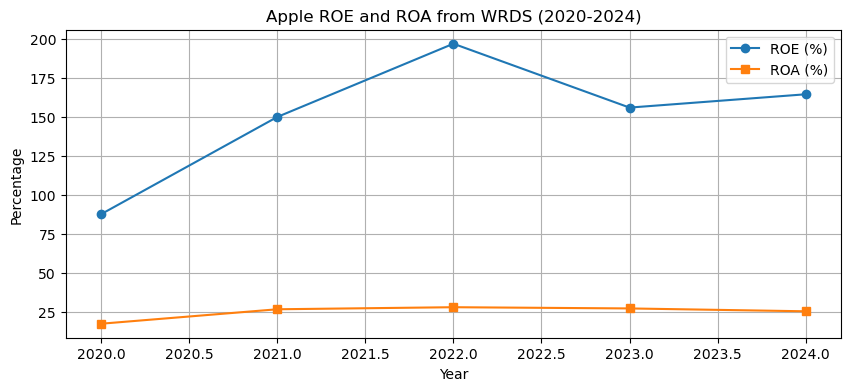

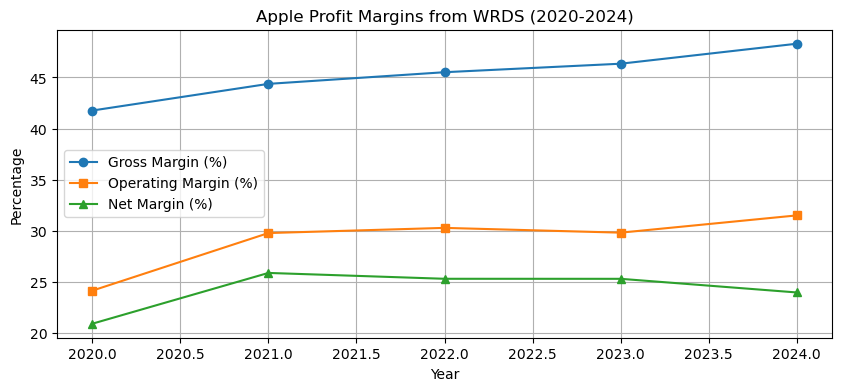

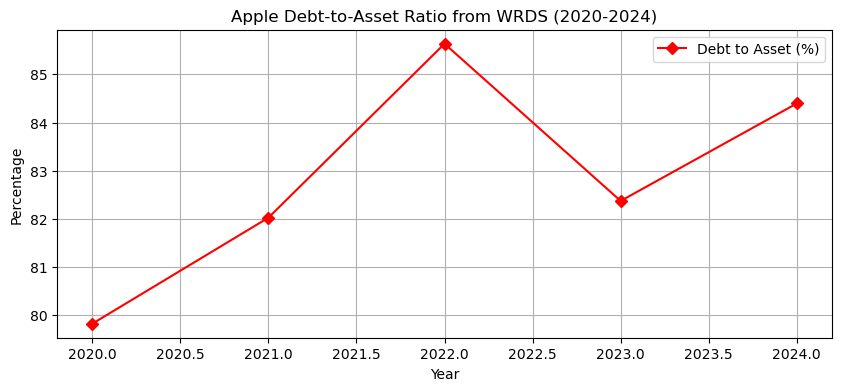

In [7]:
plt.figure(figsize=(10,4))
plt.plot(df['Year'], df['ROE'] * 100, marker='o', label='ROE (%)')
plt.plot(df['Year'], df['ROA'] * 100, marker='s', label='ROA (%)')
plt.title('Apple ROE and ROA from WRDS (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,4))
plt.plot(df['Year'], df['Gross_Margin'] * 100, marker='o', label='Gross Margin (%)')
plt.plot(df['Year'], df['Operating_Margin'] * 100, marker='s', label='Operating Margin (%)')
plt.plot(df['Year'], df['Net_Margin'] * 100, marker='^', label='Net Margin (%)')
plt.title('Apple Profit Margins from WRDS (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,4))
plt.plot(df['Year'], df['Debt_to_Asset'] * 100, marker='D', color='red', label='Debt to Asset (%)')
plt.title('Apple Debt-to-Asset Ratio from WRDS (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.grid(True)
plt.legend()
plt.show()


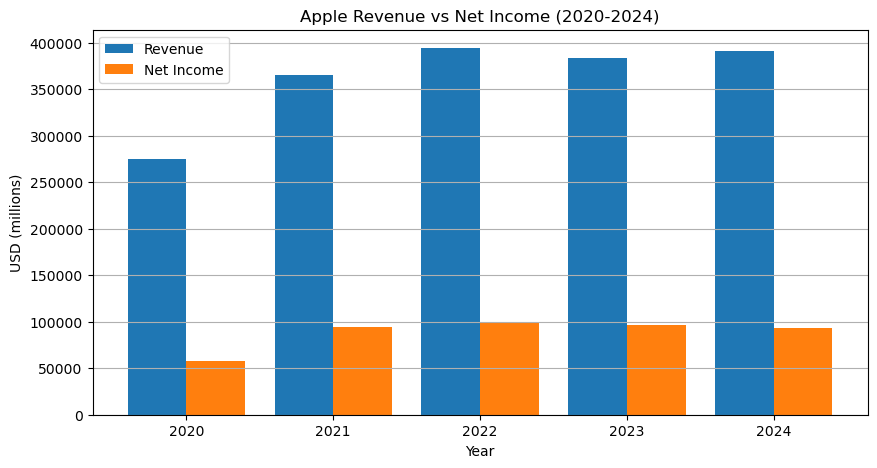

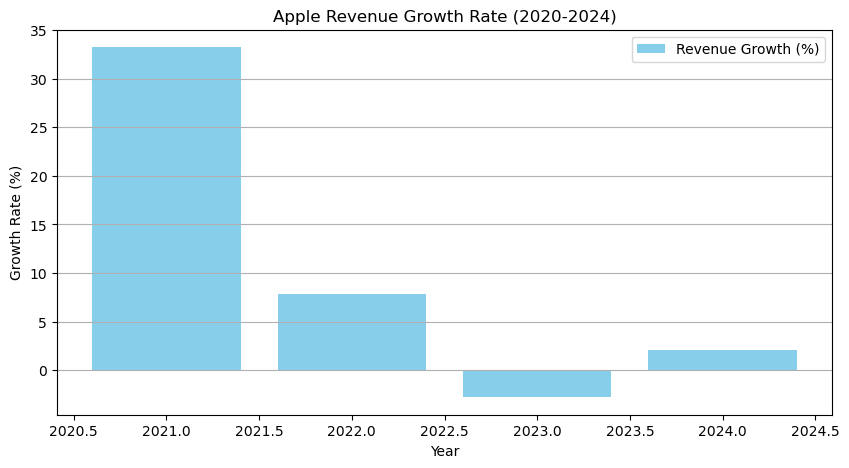

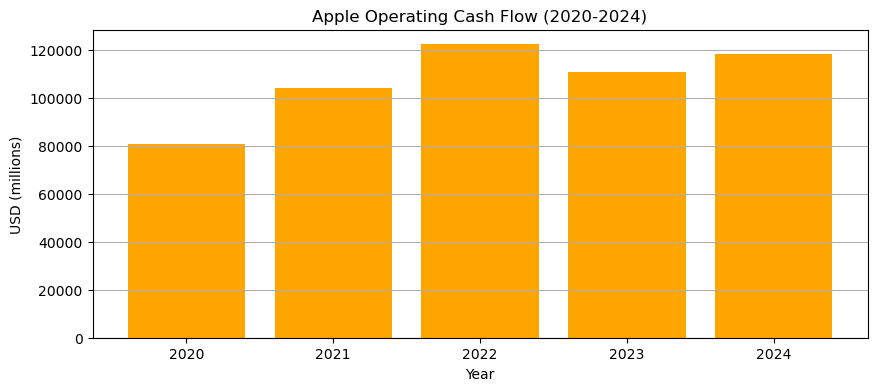

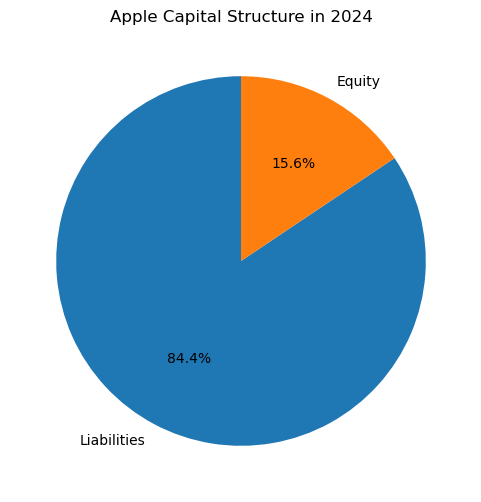

In [8]:
plt.figure(figsize=(10,5))
x = range(len(df))
plt.bar([i - 0.2 for i in x], df['Revenue'], width=0.4, label='Revenue')
plt.bar([i + 0.2 for i in x], df['Net_Income'], width=0.4, label='Net Income')
plt.xticks(x, df['Year'])
plt.title('Apple Revenue vs Net Income (2020-2024)')
plt.xlabel('Year')
plt.ylabel('USD (millions)')
plt.legend()
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(10,5))
plt.bar(df['Year'], df['Revenue_Growth'] * 100, color='skyblue', label='Revenue Growth (%)')
plt.title('Apple Revenue Growth Rate (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(10,4))
plt.bar(df['Year'], df['Operating_Cash_Flow'], color='orange')
plt.title('Apple Operating Cash Flow (2020-2024)')
plt.xlabel('Year')
plt.ylabel('USD (millions)')
plt.grid(axis='y')
plt.show()

latest = df[df['Year'] == 2024].iloc[0]

plt.figure(figsize=(6,6))
plt.pie(
    [latest['Total_Liabilities'], latest['Equity']],
    labels=['Liabilities', 'Equity'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Apple Capital Structure in 2024')
plt.show()

In [9]:
print("\nConclusions:")
print("1. Apple maintained strong profitability throughout 2020-2024.")
print("2. Both gross margin and net margin stayed relatively stable, indicating effective cost control and operational efficiency.")
print("3. ROE remained consistently above ROA, suggesting that Apple generated strong returns for shareholders.")
print("4. The debt-to-asset ratio was relatively high but did not show extreme fluctuations, implying a stable capital structure.")
print("5. Overall, the ratio analysis suggests that Apple remained financially strong, profitable, and resilient over the period.")


Conclusions:
1. Apple maintained strong profitability throughout 2020-2024.
2. Both gross margin and net margin stayed relatively stable, indicating effective cost control and operational efficiency.
3. ROE remained consistently above ROA, suggesting that Apple generated strong returns for shareholders.
4. The debt-to-asset ratio was relatively high but did not show extreme fluctuations, implying a stable capital structure.
5. Overall, the ratio analysis suggests that Apple remained financially strong, profitable, and resilient over the period.
